---
title: "Case Study: Movie Recommender System"
subtitle: PSTAT 134 (Winter 2026)
format:
    clean-revealjs:
        bibliographystyle: "chicago-author-date"
        fig-width: 30
        code-copy: hover
        code-line-numbers: true
author:
  - name: Sang-Yun Oh
    affiliations: "University of California, Santa Barbara"
date-format: long
bibliography: [../static/references.bib]
execute:
  echo: true
editor:
  render-on-save: true
---

## Movie Recommender System: Latent Factor Analysis

Map users and movies into the same space:

![Interpretation of matrix factor subspaces](images/recommender-latent-factor.png)



## Movie Recommender System: Alternating Least Squares

How do we compute matrix factors $U$ and $V$?

![Representing movie data as matrix factors](images/movie-latent-factors.png)

Alternating least squares alternates between updating $U$ and $V$.


## Movie Lense Data

Objective: build a basic recommender system using [Movie Lense 100K dataset](https://grouplens.org/datasets/movielens/).

First, download the data:

In [1]:
! wget -q http://files.grouplens.org/datasets/movielens/ml-100k.zip -O movie-lense.zip\
    && unzip -o movie-lense.zip

Archive:  movie-lense.zip
  inflating: ml-100k/allbut.pl       
  inflating: ml-100k/mku.sh          
  inflating: ml-100k/README          
  inflating: ml-100k/u.data          
  inflating: ml-100k/u.genre         
  inflating: ml-100k/u.info          
  inflating: ml-100k/u.item          
  inflating: ml-100k/u.occupation    
  inflating: ml-100k/u.user          
  inflating: ml-100k/u1.base         
  inflating: ml-100k/u1.test         
  inflating: ml-100k/u2.base         
  inflating: ml-100k/u2.test         
  inflating: ml-100k/u3.base         
  inflating: ml-100k/u3.test         
  inflating: ml-100k/u4.base         
  inflating: ml-100k/u4.test         
  inflating: ml-100k/u5.base         
  inflating: ml-100k/u5.test         
  inflating: ml-100k/ua.base         
  inflating: ml-100k/ua.test         
  inflating: ml-100k/ub.base         
  inflating: ml-100k/ub.test         


## Metadata: Rating, User, and Movie Raw Data

::: {.incremental}
* `u.data`: The full u data set, 100000 ratings by 943 users on 1682 items  
* `u.item`: Information about the items (movies).  
* `u.genre`: A list of the genres.
* `u.user`: Demographic information about the users  
* `u.occupation`: A list of the occupations.
:::

## Raw Data: Ratings

File name: `u.data`

- 100000 movie ratings by 943 users on 1682 items  

- Columns:
  ```
  user id | item id | rating | timestamp
  ```

- Data rows:

In [2]:
!head ml-100k/u.data

196	242	3	881250949
186	302	3	891717742
22	377	1	878887116
244	51	2	880606923
166	346	1	886397596
298	474	4	884182806
115	265	2	881171488
253	465	5	891628467
305	451	3	886324817
6	86	3	883603013


## Raw Data: Movie information


File name: `u.item`

- Information about the items (movies)

- Columns:
  ```
  movie id | movie title | release date | video release date |
  IMDb URL | unknown | Action | Adventure | ... 
  ```

- Data rows:

In [3]:
!head -n7 ml-100k/u.item

1|Toy Story (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Toy%20Story%20(1995)|0|0|0|1|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0
2|GoldenEye (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?GoldenEye%20(1995)|0|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0
3|Four Rooms (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Four%20Rooms%20(1995)|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0
4|Get Shorty (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Get%20Shorty%20(1995)|0|1|0|0|0|1|0|0|1|0|0|0|0|0|0|0|0|0|0
5|Copycat (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Copycat%20(1995)|0|0|0|0|0|0|1|0|1|0|0|0|0|0|0|0|1|0|0
6|Shanghai Triad (Yao a yao yao dao waipo qiao) (1995)|01-Jan-1995||http://us.imdb.com/Title?Yao+a+yao+yao+dao+waipo+qiao+(1995)|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|0|0|0|0
7|Twelve Monkeys (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Twelve%20Monkeys%20(1995)|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|1|0|0|0


## Raw Data: User information

File name: `u.user`

- Demographic information about the users  

- Columns:
  ```
  user id | age | gender | occupation | zip code
  ```

- Data rows:

In [4]:
!head ml-100k/u.user

1|24|M|technician|85711
2|53|F|other|94043
3|23|M|writer|32067
4|24|M|technician|43537
5|33|F|other|15213
6|42|M|executive|98101
7|57|M|administrator|91344
8|36|M|administrator|05201
9|29|M|student|01002
10|53|M|lawyer|90703


## Raw Data: Users and Movie Genres

* `u.genre`: A list of the genres.

* `u.occupation`: A list of the occupations.


## Import Data: Custom Module

Before importing data, creating a module is a good practice to reuse code.

::: {.incremental}
* Modules are imported from various location: run `python -m site`

In [5]:
#| echo: false
! python -m site

sys.path = [
    '/home/jovyan/work/lecture-slides',
    '/opt/conda/lib/python313.zip',
    '/opt/conda/lib/python3.13',
    '/opt/conda/lib/python3.13/lib-dynload',
    '/opt/conda/lib/python3.13/site-packages',
]
USER_BASE: '/home/jovyan/.local' (exists)
USER_SITE: '/home/jovyan/.local/lib/python3.13/site-packages' (doesn't exist)
ENABLE_USER_SITE: True


* Current directory is in the search path

* Create a module, `movielense`, in current directory with file, `movielense.py`

* Then, import this local module by executing `import movielense`
:::


## 


::: {.panel-tabset}

## User Module

Reload modules if modified:

In [6]:
#| code-fold: true
#| code-summary: "Reloading if module movielense.py changes"
%load_ext autoreload
%autoreload 2

Create a file with contents below:

In [7]:
%%writefile movielense.py
import numpy as np
import pandas as pd
from pathlib import Path

Overwriting movielense.py


## Import Users

In [8]:
%%writefile -a movielense.py
def import_users(user_filename):
    """
    Imports Movie Lense user data into Pandas DataFrame
    
    user_filename: e.g. location of file `ml-100k/u.data` from
        http://files.grouplens.org/datasets/movielens/ml-100k.zip
        
    """
    users_list   = [l.split('|')  for l in Path(user_filename).read_text().split('\n')]
    return pd.DataFrame(
        users_list,
        columns='user id | age | gender | occupation | zip code'.split(' | '),
    ).dropna().astype(
        {'user id':'int', 'age':'int', 'gender':'str', 'occupation':'str', 'zip code':'str'}
    ).set_index('user id')

Appending to movielense.py


## Import Movies

In [9]:
%%writefile -a movielense.py
def import_movies(movies_filename):
    """
    Imports Movie Lense movies data into Pandas DataFrame
    
    movies_filename: e.g. location of file `ml-100k/u.item` from 
        http://files.grouplens.org/datasets/movielens/ml-100k.zip
        
    """
    movies_list  = [l.split('|')  for l in Path(movies_filename).read_text(encoding = "ISO-8859-1").split('\n')]
    movies = pd.DataFrame(
        movies_list,
        columns='movie id | movie title | release date | video release date | '\
            'IMDb URL | unknown | Action | Adventure | Animation | '\
            'Children\'s | Comedy | Crime | Documentary | Drama | Fantasy | '\
            'Film-Noir | Horror | Musical | Mystery | Romance | Sci-Fi | '\
            'Thriller | War | Western'.split(' | '),
    ).dropna()

    d = {'movie id':'int', 'movie title':'str', 'release date':'datetime64[ns]', 'video release date':'datetime64[ns]', 'IMDb URL':'str', 'Action':'int'}
    genre_columns = movies.columns[-19:]
    
    return movies.astype(d).astype(dict(zip(genre_columns, [int]*19))).astype(dict(zip(genre_columns, [bool]*19))).set_index('movie id')

Appending to movielense.py


## Import Ratings

In [10]:
%%writefile -a movielense.py
def import_ratings(data_filename, movies=None):
    """
    Imports Movie Lense ratings data into Pandas DataFrame
    
    data_filename: e.g. location of file `ml-100k/u.data` from 
        http://files.grouplens.org/datasets/movielens/ml-100k.zip
    movies: DataFrame resulting from `import_users`
    
    """
    
    ratings_list = [l.split('\t') for l in Path(data_filename).read_text().split('\n')]
    
    ratings = pd.DataFrame(
        ratings_list,
        columns='user id | item id | rating | timestamp'.split(' | ')
    ).dropna().astype({'timestamp':'int'}).astype(
        {'user id':'int', 'item id':'int', 'rating':'int', 'timestamp':'datetime64[s]'}
    ).rename(columns={'item id':'movie id'}).set_index(['user id','movie id']).drop(columns=['timestamp'])
    
    if (movies is not None):
        ratings = ratings.join(movies['movie title'], on='movie id').set_index('movie title', append=True)
        
    return ratings

Appending to movielense.py


In [11]:
import pandas as pd
import altair as alt
import numpy as np
import movielense as ml

users = ml.import_users('ml-100k/u.user')
movies = ml.import_movies('ml-100k/u.item')
ratings = ml.import_ratings('ml-100k/u.data', movies)

In [12]:
users.head()

,age,gender,occupation,zip code
user id,,,,
1,24,M,technician,85711
2,53,F,other,94043
3,23,M,writer,32067
4,24,M,technician,43537
5,33,F,other,15213


In [13]:
movies.head(3)

,movie title,release date,video release date,IMDb URL,unknown,Action,Adventure,Animation,Children's,Comedy,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movie id,,,,,,,,,,,,,,,,,,,,,
1,Toy Story (1995),1995-01-01,NaT,http://us.imdb.com/M/title-exact?Toy%20Story%2...,False,False,False,True,True,True,...,False,False,False,False,False,False,False,False,False,False
2,GoldenEye (1995),1995-01-01,NaT,http://us.imdb.com/M/title-exact?GoldenEye%20(...,False,True,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,Four Rooms (1995),1995-01-01,NaT,http://us.imdb.com/M/title-exact?Four%20Rooms%...,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [14]:
ratings.head()

,,,rating
user id,movie id,movie title,
196,242,Kolya (1996),3
186,302,L.A. Confidential (1997),3
22,377,Heavyweights (1994),1
244,51,Legends of the Fall (1994),2
166,346,Jackie Brown (1997),1


## Transforming Data

Ratings Matrix

* Rating matrix: $R = ((r_{mi}))$
* Movies (rows): $m=1,2,\dots,M$
* Individuals (columns): $i=1,2,\dots,I$

## Visualize Ratings Matrix

In [15]:
R_all = ratings.unstack(['user id'])
R_all

rating                    \
user id                                               1    2   3   4    5     
movie id movie title                                                          
1        Toy Story (1995)                             5.0  4.0 NaN NaN  4.0   
2        GoldenEye (1995)                             3.0  NaN NaN NaN  3.0   
3        Four Rooms (1995)                            4.0  NaN NaN NaN  NaN   
4        Get Shorty (1995)                            3.0  NaN NaN NaN  NaN   
5        Copycat (1995)                               3.0  NaN NaN NaN  NaN   
...                                                   ...  ...  ..  ..  ...   
1678     Mat' i syn (1997)                            NaN  NaN NaN NaN  NaN   
1679     B. Monkey (1998)                             NaN  NaN NaN NaN  NaN   
1680     Sliding Doors (1998)                         NaN  NaN NaN NaN  NaN   
1681     You So Crazy (1994)                          NaN  NaN NaN NaN  NaN   
1682     Scream of Stone (Schrei aus Stein) (1991)    NaN  NaN NaN NaN  NaN   

                                                                           \
user id                                             6    7   8   9    10    
movie id movie title                                                        
1        Toy Story (1995)                           4.0  NaN NaN NaN  4.0   
2        GoldenEye (1995)                           NaN  NaN NaN NaN  NaN   
3        Four Rooms (1995)                          NaN  NaN NaN NaN  NaN   
4        Get Shorty (1995)                          NaN  5.0 NaN NaN  4.0   
5        Copycat (1995)                             NaN  NaN NaN NaN  NaN   
...                                                 ...  ...  ..  ..  ...   
1678     Mat' i syn (1997)                          NaN  NaN NaN NaN  NaN   
1679     B. Monkey (1998)                           NaN  NaN NaN NaN  NaN   
1680     Sliding Doors (1998)                       NaN  NaN NaN NaN  NaN   
1681     You So Crazy (1994)                        NaN  NaN NaN NaN  NaN   
1682     Scream of Stone (Schrei aus Stein) (1991)  NaN  NaN NaN NaN  NaN   

                                                    ...                     \
user id                                             ...  934  935  936 937   
movie id movie title                                ...                      
1        Toy Story (1995)                           ...  2.0  3.0  4.0 NaN   
2        GoldenEye (1995)                           ...  4.0  NaN  NaN NaN   
3        Four Rooms (1995)                          ...  NaN  NaN  4.0 NaN   
4        Get Shorty (1995)                          ...  5.0  NaN  NaN NaN   
5        Copycat (1995)                             ...  NaN  NaN  NaN NaN   
...                                                 ...  ...  ...  ...  ..   
1678     Mat' i syn (1997)                          ...  NaN  NaN  NaN NaN   
1679     B. Monkey (1998)                           ...  NaN  NaN  NaN NaN   
1680     Sliding Doors (1998)                       ...  NaN  NaN  NaN NaN   
1681     You So Crazy (1994)                        ...  NaN  NaN  NaN NaN   
1682     Scream of Stone (Schrei aus Stein) (1991)  ...  NaN  NaN  NaN NaN   

                                                                                
user id                                             938 939  940  941 942  943  
movie id movie title                                                            
1        Toy Story (1995)                           4.0 NaN  NaN  5.0 NaN  NaN  
2        GoldenEye (1995)                           NaN NaN  NaN  NaN NaN  5.0  
3        Four Rooms (1995)                          NaN NaN  NaN  NaN NaN  NaN  
4        Get Shorty (1995)                          NaN NaN  2.0  NaN NaN  NaN  
5        Copycat (1995)                             NaN NaN  NaN  NaN NaN  NaN  
...                                                 ...  ..  ...  ...  ..  ...  
1678     Mat' i syn (1997)                 

## Create Small Subset of Data

Most ratings are missing: `{python} np.round(np.isnan(R_all).mean().mean()*100, 2)`% of ratings are missing

In [16]:
#| code-fold: true
#| code-summary: "Create a small subset of data"
I = 16
M = 15

# retrieve movies/users combination that is not *too* sparse
top_users = R_all.agg('sum', axis=0).nlargest(70).tail(I).sort_index().index
top_movies = R_all.agg('sum', axis=1).nlargest(70).tail(M).sort_index().index

Rdf = R_all.loc[top_movies, top_users]
Rdf

rating                           \
user id                                         1    85   178  269  271  299   
movie id movie title                                                           
82       Jurassic Park (1993)                   5.0  3.0  5.0  2.0  NaN  NaN   
97       Dances with Wolves (1990)              3.0  2.0  5.0  NaN  5.0  4.0   
111      Truth About Cats & Dogs, The (1996)    5.0  NaN  4.0  1.0  4.0  3.0   
132      Wizard of Oz, The (1939)               4.0  5.0  NaN  5.0  5.0  NaN   
185      Psycho (1960)                          4.0  NaN  NaN  5.0  3.0  3.0   
186      Blues Brothers, The (1980)             4.0  3.0  NaN  2.0  4.0  3.0   
194      Sting, The (1973)                      4.0  4.0  4.0  5.0  5.0  3.0   
196      Dead Poets Society (1989)              5.0  4.0  4.0  1.0  4.0  NaN   
197      Graduate, The (1967)                   5.0  5.0  2.0  5.0  4.0  3.0   
238      Raising Arizona (1987)                 4.0  2.0  4.0  5.0  4.0  4.0   
268      Chasing Amy (1997)                     5.0  4.0  4.0  5.0  NaN  NaN   
475      Trainspotting (1996)                   NaN  NaN  NaN  5.0  NaN  4.0   
496      It's a Wonderful Life (1946)           NaN  4.0  NaN  5.0  5.0  3.0   
742      Ransom (1996)                          NaN  NaN  3.0  NaN  3.0  4.0   
748      Saint, The (1997)                      NaN  NaN  4.0  NaN  NaN  NaN   

                                                                            \
user id                                       301  312  328  339  387  389   
movie id movie title                                                         
82       Jurassic Park (1993)                 5.0  NaN  4.0  4.0  4.0  4.0   
97       Dances with Wolves (1990)            4.0  5.0  3.0  4.0  2.0  NaN   
111      Truth About Cats & Dogs, The (1996)  1.0  NaN  NaN  NaN  NaN  3.0   
132      Wizard of Oz, The (1939)             4.0  5.0  5.0  5.0  NaN  5.0   
185      Psycho (1960)                        NaN  5.0  4.0  4.0  NaN  5.0   
186      Blues Brothers, The (1980)           4.0  3.0  4.0  4.0  2.0  2.0   
194      Sting, The (1973)                    4.0  4.0  3.0  4.0  3.0  4.0   
196      Dead Poets Society (1989)            4.0  NaN  NaN  4.0  2.0  3.0   
197      Graduate, The (1967)                 5.0  4.0  NaN  5.0  2.0  5.0   
238      Raising Arizona (1987)               NaN  3.0  NaN  5.0  5.0  5.0   
268      Chasing Amy (1997)                   NaN  NaN  NaN  NaN  3.0  NaN   
475      Trainspotting (1996)                 NaN  NaN  NaN  5.0  3.0  5.0   
496      It's a Wonderful Life (1946)         5.0  5.0  NaN  5.0  3.0  4.0   
742      Ransom (1996)                        4.0  NaN  4.0  NaN  2.0  NaN   
748      Saint, The (1997)                    NaN  NaN  3.0  NaN  NaN  NaN   

                                                                  
user id                                       650  716  727  883  
movie id movie title                                              
82       Jurassic Park (1993)                 3.0  5.0  3.0  3.0  
97       Dances with Wolves (1990)            3.0  4.0  NaN  NaN  
111      Truth About Cats & Dogs, The (1996)  NaN  4.0  3.0  NaN  
132      Wizard of Oz, The (1939)             4.0  5.0  2.0  NaN  
185      Psycho (1960)                        3.0  5.0  NaN  5.0  
186      Blues Brothers, The (1980)           4.0  3.0  5.0  NaN  
194      Sting, The (1973)                    4.0  5.0  NaN  3.0  
196      Dead Poets Society (1989)            4.0  5.0  4.0  NaN  
197      Graduate, The (1967)                 4.0  5.0  3.0  4.0  
238      Raising Arizona (1987)               4.0  4.0  2.0  4.0  
268      Chasing Amy (1997)                   NaN  NaN  4.0  NaN  
475      Trainspotting (1996)                 NaN  NaN  NaN  NaN  
496      It's a Wonderful Life (1946)         4.0  5.0  NaN  2.0  
742      Ransom (1996)                        3.0  NaN  NaN  NaN  
748      Saint, The (1997)                    NaN  NaN  4.0 

## Visualizing Missing Values

Zeros indicate missing ratings. To visualize the missing values, plot the following heatmap

In [17]:
#| code-fold: true
#| code-summary: "Visualize missing rating values"

long = lambda x: x.stack().reset_index()

# https://altair-viz.github.io/user_guide/encoding.html#encoding-data-types
alt.Chart(long(Rdf)).mark_rect().encode(
    x='user id:O',
    y='movie title:O',
    color=alt.Color('rating:O', scale=alt.Scale(scheme='yellowgreenblue'))
)

/tmp/ipykernel_369924/1746393546.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = lambda x: x.stack().reset_index()


alt.Chart(...)

## Scalar Ratings: Users and Movies

Model rating $r_{mi}$ of movie $m$ by user $i$:
$$ \hat r_{mi} = \sum_{k=1}^K v_{mk} u_{ik} = v_{m} u_{i}^T $$
Note that $v_m$ and $u_i$ are **row vectors**.

* $K$ unobserved characteristics (latent factors)
* Characteristic index: $k=1,\dots,K$
* $v_m=(v_{m1},\dots,v_{mK})$: $K$-vector for movie $m$
* $u_i=(u_{i1},\dots,u_{iK})$: $K$-vector for user $i$
* Rating $r_{mi}$ is high if $v_m$ and $u_i$ are well-aligned

## Ratings Matrix: Users and Movies Matrices

$U$ and $V$ as matrix factors

$$
\begin{aligned}
&\min_{U,V} \|R - V U^T\|_F^2
\end{aligned}
$$

- Ratings matrix $R$: size $M\times I$ 
- Movies matrix $V$: size $M\times K$
- Users matrix $U$: size  $I\times K$

## Fix $K$ and initialize $U$ and $V$



In [18]:
#| code-fold: show
# number of latent factors
K = 3

# initialize U and V with random values
np.random.seed(42)

R = Rdf['rating'].droplevel('movie title')
# R = Rdf.values       # get the values as numpy array

U = np.random.uniform(0, 1, size=K*I).reshape((I, K))
V = np.random.uniform(0, 1, size=K*M).reshape((M, K))

U = pd.DataFrame(U, index=R.columns)
V = pd.DataFrame(V, index=R.index)

Uold = np.zeros_like(U)
Vold = np.zeros_like(V)

U.shape

(16, 3)


## Ratings Matrix: Users and Movies Matrices

Above formulation is conceptually fine; however, the observed ratings matrix $R$ has many missing elements. This will create a problem when we compute the Frobenius norm. So, we modify equation to the following involving an indicator function:
$$
\begin{aligned}
I_{mi} = \begin{cases}
1 \text{, if rating $r_{mi}$ is observed}\\
0 \text{, otherwise}\\
\end{cases}.
\end{aligned}
$$

Now we can evaluate objective function for observed $r_{mi}$ only:
$$
\begin{aligned}
\min_{U,V} \|R - V U^T\|_F^2
=\min_{U,V} \left\{ \sum_{m=1}^M \sum_{i=1}^I I_{mi}(r_{mi} - v_m u_i^T)^2 \right\}.
\end{aligned}
$$

Now, iteratively compute optimal solutions $U$ and $V$. This problem is in the form of alternating least squares. Alternating least squares (ALS) is named because it alternates between fixing one factor matrix and solving a least squares problem for the other, then swapping back and forth until convergence.

To implement an ALS solver, we identify the exact form of subproblems and iteratively solve them.

### Updating $u_i$

Suppose we fix $K=3$. If user $i$ watched and rated all movies being considered, there will be $M$ ratings. Suppose we collect all equations with fixed $i$. For illustration, assume user $i$ watched movies $m\in \{2,3,7,9\} = W$. (We are denoting the set of movies watched as $W$) Then, we need to consider

$$
\begin{aligned}
\begin{pmatrix}
r_{2i} \\
r_{3i} \\
r_{7i} \\
r_{9i} \\
\end{pmatrix} =
\begin{pmatrix}
-\, v_{2}\, - \\
-\, v_{3}\, - \\
-\, v_{7}\, - \\
-\, v_{9}\, - \\
\end{pmatrix}
\begin{pmatrix}
| \\
u_{i} \\
| \\
\end{pmatrix}
\end{aligned}
$$

With all $v_m$ fixed, the problem becomes identical to ordinary least squares with response being the observed ratings, design matrix being the collection of $v_m$'s. Then $u_i$ represents the OLS coefficients.

Let's implement the update for user ID `883`.

In [19]:
user_id = 883
movies_rated = R.loc[:, user_id].dropna().index

R_Wi = R.loc[movies_rated, user_id]
U_i = U.loc[user_id,:]
V_W = V.loc[movies_rated,:]

import scipy.linalg as la

# solve || R_Wi - V_W @ U_i ||

U_i, r_i, _, _ = la.lstsq(V_W, R_Wi)

### Updating $v_m$

Let's implement the update for movie ID `82`.

In [20]:
movie_id = 82
users_rated = R.loc[movie_id, :].dropna().index

R_mW = R.loc[movie_id, users_rated]
U_W = U.loc[users_rated,:]
V_m = V.loc[movie_id,:]

import scipy.linalg as la

# solve || R_mW - U_W @ V_m ||

V_m, r_m, _, _ = la.lstsq(U_W, R_mW)

We can combine both updates as one function.

In [21]:
def Update_U_V(R, U, V, user_id=None, movie_id=None):

  assert (user_id is None) != (movie_id is None), "Exactly one of user_id or movie_id must be specified"

  if user_id is not None:

    movies_rated = R.loc[:, user_id].dropna().index

    R_Wi = R.loc[movies_rated, user_id]
    U_i = U.loc[user_id,:]
    V_W = V.loc[movies_rated,:]

    U_i, _, _, _ = la.lstsq(V_W, R_Wi)
    rel_update = (U.loc[user_id,:] - U_i) / U.loc[user_id,:]
    update = np.max(np.abs(rel_update))
    U.loc[user_id,:] = U_i

  else:

    users_rated = R.loc[movie_id, :].dropna().index

    R_mW = R.loc[movie_id, users_rated]
    U_W = U.loc[users_rated,:]
    V_m = V.loc[movie_id,:]

    V_m, _, _, _ = la.lstsq(U_W, R_mW)
    rel_update = (V.loc[movie_id,:] - V_m) / V.loc[movie_id,:]
    update = np.max(np.abs(rel_update))
    V.loc[movie_id,:] = V_m

  return U, V, update

Now let's write a loop to apply updates for each user then each movie. For ALS, we need at least one review to be able to update coefficients. Therefore, let's make sure all users have non-empty ratings and all movies have non-empty ratings.

In [22]:
users_with_ratings = R.dropna(how='all', axis=1).columns
movie_with_ratings = R.dropna(how='all', axis=0).index

print("users with any ratings:\n", users_with_ratings)
print("movies with any ratings:\n", movie_with_ratings)

users with any ratings:
 Index([1, 85, 178, 269, 271, 299, 301, 312, 328, 339, 387, 389, 650, 716, 727,
       883],
      dtype='int64', name='user id')
movies with any ratings:
 Index([82, 97, 111, 132, 185, 186, 194, 196, 197, 238, 268, 475, 496, 742,
       748],
      dtype='int64', name='movie id')


## Preparing to Optimize: Part 3

* Decide metric for improvement (root mean square error):
  $$ \text{RMSE}(x, y) = \left[\frac{1}{n}\sum_{i=1}^{n} \|x_i - y_i\|_2^2 \right]^{1/2},$$
  where matrices $x$ and $y$ are first vectorized

* Keep track of updates to $U$ and $V$:
  $$ \text{MaxUpdate}(U^{\text{(old)}}, U^{\text{(new)}}) = \left\|\frac{U^{\text{(old)}}-U^{\text{(new)}}}{U^{\text{(new)}}}\right\|_\infty,$$
  where difference, ratio, and matrix norm is computed element-wise.

In [23]:
#| code-fold: show
# calculate RMSE
def rmse(X, Y):
    from numpy import sqrt, nanmean
    return sqrt(nanmean((X - Y)**2))

error = [(0, rmse(R, np.inner(V,U)))]

# calculate maximum magnitude of relative updates
def max_update(X, Y):
    from numpy import inf
    from numpy.linalg import norm
    return norm(((X - Y)/Y).values.ravel(), inf)

update = [(0, max(max_update(Uold, U), max_update(Vold, V)))]


In [24]:
max_iterations = 300
update = []

for t in range(1, max_iterations):

  rmse_error = rmse(R, np.inner(V,U))

  for i in users_with_ratings:
    U, _, update_u = Update_U_V(R, U, V, user_id=i)
    # print(f"User {i} updated with max relative change {update_u:.6f}")
  
  for m in movie_with_ratings:
    _, V, update_v = Update_U_V(R, U, V, movie_id=m)
    # print(f"Movie {m} updated with max relative change {update_v:.6f}")
  
  update += [(t, rmse_error, max(update_u, update_v))]
  
update = pd.DataFrame(update , columns=['iteration', 'rmse', 'maximum update'])

## Monitoring Optimization Progress

As gradient descent progresses,
* $U$ and $V$ are updated. How large are the updates?
* Are the updates getting better? Does RMSE decrease?

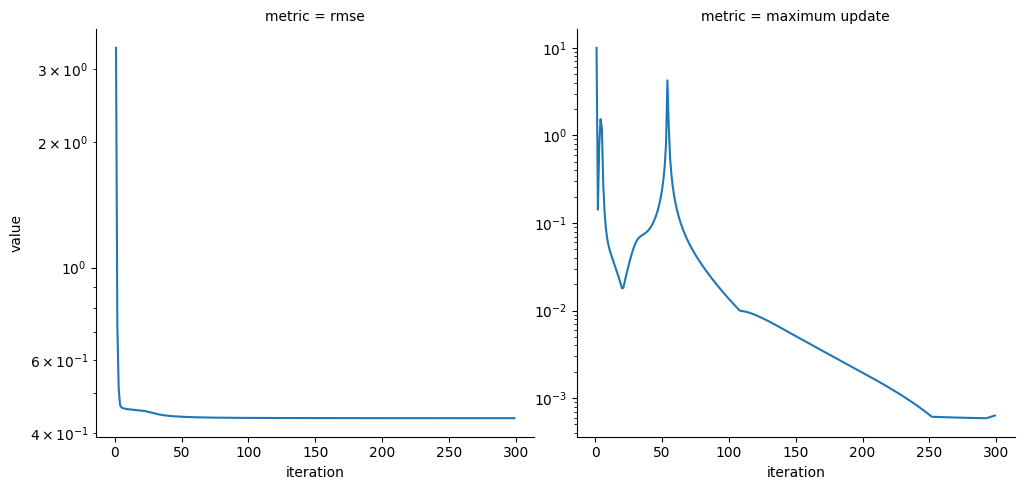

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = update.melt(
    id_vars='iteration',
    value_vars=['rmse', 'maximum update'],
    var_name='metric',
    value_name='value'
)

g = sns.relplot(
    data=plot_df,
    x='iteration',
    y='value',
    col='metric',
    kind='line',
    facet_kws={'sharey': False}
)

for ax in g.axes.flat:
    ax.set_yscale('log')

plt.show()

## Visualize Results

Comparison Data Frame:

* `observed`: observed ratings , $R$
* `fit`: calculated ratings $\hat r_{mi}$  if $r_{mi}$ is observed
* `fit/prediction`: $\hat R = VU^T$
* `deviation`: $(\hat r_{mi} - r_{mi})\cdot I_{mi}$, where $I_{mi}$ indicates if user $i$ rated movie $m$

In [26]:
Rone = pd.DataFrame().reindex_like(Rdf).replace(np.nan, 1)
# multiplying by Rone copies DataFrame structure
Rhat = np.inner(V, U) * Rone 
Rhat_if_obs = Rhat.where(~np.isnan(Rdf), np.nan)
Rhat_if_obs


rating                      \
user id                                            1         85        178   
movie id movie title                                                         
82       Jurassic Park (1993)                 4.486030  2.820968  3.829870   
97       Dances with Wolves (1990)            3.233166  1.985328  5.115904   
111      Truth About Cats & Dogs, The (1996)  5.001026       NaN  4.002148   
132      Wizard of Oz, The (1939)             4.668441  5.164773       NaN   
185      Psycho (1960)                        4.000587       NaN       NaN   
186      Blues Brothers, The (1980)           3.798635  3.071241       NaN   
194      Sting, The (1973)                    4.381540  3.706745  3.581552   
196      Dead Poets Society (1989)            4.206261  3.950114  3.860747   
197      Graduate, The (1967)                 4.583712  4.673953  3.657770   
238      Raising Arizona (1987)               4.491657  2.064313  3.573855   
268      Chasing Amy (1997)                   5.111634  4.284211  4.252178   
475      Trainspotting (1996)                      NaN       NaN       NaN   
496      It's a Wonderful Life (1946)              NaN  4.217255       NaN   
742      Ransom (1996)                             NaN       NaN  2.944622   
748      Saint, The (1997)                         NaN       NaN  4.114734   

                                                                            \
user id                                            269       271       299   
movie id movie title                                                         
82       Jurassic Park (1993)                 3.470735       NaN       NaN   
97       Dances with Wolves (1990)                 NaN  5.127722  3.722955   
111      Truth About Cats & Dogs, The (1996)  1.002399  4.007093  3.004978   
132      Wizard of Oz, The (1939)             5.185956  4.331762       NaN   
185      Psycho (1960)                        5.495667  3.566278  2.961584   
186      Blues Brothers, The (1980)           1.385115  3.944710  3.137936   
194      Sting, The (1973)                    4.295408  4.143848  3.378086   
196      Dead Poets Society (1989)            1.787945  4.333506       NaN   
197      Graduate, The (1967)                 5.006562  4.263218  3.493005   
238      Raising Arizona (1987)               4.904822  4.160029  3.406706   
268      Chasing Amy (1997)                   4.600409       NaN       NaN   
475      Trainspotting (1996)                 4.984806       NaN  3.884827   
496      It's a Wonderful Life (1946)         4.006938  4.729120  3.829570   
742      Ransom (1996)                             NaN  3.563686  2.995414   
748      Saint, The (1997)                         NaN       NaN       NaN   

                                                                            \
user id                                            301       312       328   
movie id movie title                                                         
82       Jurassic Park (1993)                 4.468792       NaN  4.124356   
97       Dances with Wolves (1990)            4.015506  4.900320  3.024987   
111      Truth About Cats & Dogs, The (1996)  1.000503       NaN       NaN   
132      Wizard of Oz, The (1939)             4.604820  4.751221  4.418477   
185      Psycho (1960)                             NaN  4.947320  3.891855   
186      Blues Brothers, The (1980)           3.893955  3.718640  3.539704   
194      Sting, The (1973)                    4.330985  3.902475  4.081261   
196      Dead Poets Society (1989)            4.308691       NaN       NaN   
197      Graduate, The (1967)                 4.517507  4.450850       NaN   
238      Raising Arizona (1987)                    NaN  2.908502       NaN   
268      Chasing Amy (1997)                        NaN       NaN       NaN   
475      Trainspotting (1996)                      NaN       NaN       NaN   
496      It's a Wonderful Life (1946)         4.869096  4.534303    

In [27]:
#| echo: false
# Rone is DataFrame of all ones with R's structure
Rone = pd.DataFrame().reindex_like(Rdf).replace(np.nan, 1)
# multiplying by Rone copies DataFrame structure
Rhat = np.inner(V, U) * Rone 
Rhat_if_obs = Rhat.where(~np.isnan(R), np.nan)

R_compare = \
    Rdf.rename(columns={'rating':'observed'})\
    .join(Rhat_if_obs.rename(columns={'rating':'fit'}))\
    .join(Rhat.rename(columns={'rating':'fit/prediction'}))\
    .join((Rhat_if_obs-R).rename(columns={'rating':'deviation'}))

long(R_compare).head(3)

/tmp/ipykernel_369924/1746393546.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = lambda x: x.stack().reset_index()


,movie id,movie title,user id,observed,fit,fit/prediction,deviation
0,82,Jurassic Park (1993),1,5.0,4.486030,4.486030,-0.513970
1,82,Jurassic Park (1993),85,3.0,2.820968,2.820968,-0.179032
2,82,Jurassic Park (1993),178,5.0,3.829870,3.829870,-1.170130


## Recommending Movies

**Recommendation**: unwatched movie $m$ with highest $\hat r_{mi}$

In [28]:
#| echo: false

# create new base plot
base = alt.Chart(long(R_compare)).mark_rect().encode(
    x='user id:O',
    y='movie title:O',
    tooltip=['user id', 'movie title', 'fit/prediction', 'observed', 'deviation']
)

# raw ratings data
f_raw = base\
    .properties(title='Ratings Data')\
    .encode(color=alt.Color('observed:O', scale=alt.Scale(scheme='yellowgreenblue', domain=[1,2,3,4,5])))

# fit and predicted ratings
f_all = base\
    .properties(title='Ratings Fit and Predictions')\
    .encode(color=alt.Color('fit/prediction:Q', scale=alt.Scale(scheme='yellowgreenblue', domain=[1, 5])))

# deviation between ratings data and fit
f_err = base\
    .properties(title='Deviation: Data - Fit')\
    .encode(color=alt.Color('deviation:Q', scale=alt.Scale(scheme='redblue', domain=[-2, 2])))

nearest = alt.selection_point(nearest=True, on='mouseover', empty=False) 

selectors = base.mark_square(filled=False, size=350).encode(
    x='user id:N',
    y='movie title:N',
    color=alt.value('black'),
    opacity=alt.condition(nearest, alt.value(1), alt.value(0))
).add_params(
    nearest
)

alt.hconcat(
    alt.layer(f_all.encode(color=alt.Color('fit/prediction:Q', legend=None, scale=alt.Scale(scheme='yellowgreenblue', domain=[1, 5]))),
              selectors),
    alt.layer(f_raw.encode(y=alt.Y('movie title:O', axis=alt.Axis(labels=False))),
              selectors),
).resolve_scale(color='independent')

/tmp/ipykernel_369924/1746393546.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = lambda x: x.stack().reset_index()
/opt/conda/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3701: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  exec(code_obj, self.user_global_ns, self.user_ns)


alt.HConcatChart(...)

## Recommendation: User id 85

| **Watched** | **Recommend** | **Recommend** |
| :-: | :-: | :-: | 
| **5 (observed) / 5.5 (fit/prediction)** | **5.8 (fit/prediction)** | **4.3 (fit/prediction)** |
| ![https://www.imdb.com/title/tt0032138/](https://m.media-amazon.com/images/M/MV5BNjUyMTc4MDExMV5BMl5BanBnXkFtZTgwNDg0NDIwMjE@._V1_SY1000_CR0,0,670,1000_AL_.jpg) | ![https://www.imdb.com/title/tt0117979/](https://m.media-amazon.com/images/M/MV5BOWM0MTA4NjItMzM3ZS00NDJmLTg3NWItNGE5ODIyOGJhNzQ0L2ltYWdlL2ltYWdlXkEyXkFqcGdeQXVyMTQxNzMzNDI@._V1_SY1000_CR0,0,666,1000_AL_.jpg) | ![https://www.imdb.com/title/tt0117951/](https://m.media-amazon.com/images/M/MV5BMzA5Zjc3ZTMtMmU5YS00YTMwLWI4MWUtYTU0YTVmNjVmODZhXkEyXkFqcGdeQXVyNjU0OTQ0OTY@._V1_SY1000_SX675_AL_.jpg) |
| *The Wizard of Oz (1939)* | *Truth About Cats & Dogs (1996)* | *Trainspotting (1996)*

## Recommendation: User id 727

| **Watched** | **Recommend** | **Recommend** |
| :-: | :-: |  :-: | 
| **5 (observed) / 5.2 (fit/prediction)** | **5.8 (fit/prediction)** | **4.6 (fit/prediction)** |
| ![https://www.imdb.com/title/tt0080455/](https://m.media-amazon.com/images/M/MV5BYTdlMDExOGUtN2I3MS00MjY5LWE1NTAtYzc3MzIxN2M3OWY1XkEyXkFqcGdeQXVyNzkwMjQ5NzM@._V1_.jpg) | ![https://www.imdb.com/title/tt0099348/](https://m.media-amazon.com/images/M/MV5BMTY3OTI5NDczN15BMl5BanBnXkFtZTcwNDA0NDY3Mw@@._V1_SY1000_CR0,0,666,1000_AL_.jpg) | ![https://www.imdb.com/title/tt0038650/](https://m.media-amazon.com/images/M/MV5BZjc4NDZhZWMtNGEzYS00ZWU2LThlM2ItNTA0YzQ0OTExMTE2XkEyXkFqcGdeQXVyNjUwMzI2NzU@._V1_SY1000_CR0,0,687,1000_AL_.jpg) |
| *The Blues Brothers (1980)* | *Dances with Wolves (1990)* | *It's a Wonderful Life (1946)* |

## Visualizing Errors

In [29]:
#| echo: false
selectors = base.mark_square(filled=False, size=350).encode(
    x='user id:N',
    y='movie title:N',
    color=alt.value('black'),
    opacity=alt.condition(nearest, alt.value(1), alt.value(0))
).add_params(
    nearest
)

alt.hconcat(
    alt.layer(f_all.encode(color=alt.Color('fit/prediction:Q', legend=None, scale=alt.Scale(scheme='yellowgreenblue', domain=[1, 5]))),
              selectors),
    alt.layer(f_err.encode(y=alt.Y('movie title:N', axis=alt.Axis(labels=False))),
              selectors),
).resolve_scale(color='independent')

/opt/conda/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3701: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  exec(code_obj, self.user_global_ns, self.user_ns)


alt.HConcatChart(...)

## Comparing Users or Comparing Movies

* $K$-latent factors or unobserved characteristics
* $v_{mk}$: movie $m$ having characteristic $k$
* $u_{ik}$: user $i$'s affinity to characteristic $k$

$$ \hat r_{mi} = \sum_{k=1}^K v_{mk} u_{ik} = v_{m} u_{i}^T $$

## Matrix Factors: $V$ and $U$

Compare users in $U$ and movies in $V$:

* Users $i$ and $j$ pair: $\|u_i - u_j\|^2_2$
* Movies $m$ and $n$ pair: $\|v_m - v_n\|^2_2$

In [30]:
#| echo: false
V = pd.DataFrame(V, index=R.index, 
                 columns=pd.MultiIndex.from_product([['affinity'], range(0, K)], names=[None, 'k']))
U = pd.DataFrame(U, index=R.columns.get_level_values(level='user id'),
                 columns=pd.MultiIndex.from_product([['affinity'], range(0, K)], names=[None, 'k']))
alt.hconcat(
    alt.Chart(long(V)).mark_rect().encode(x='k:N', y='movie title:N', color='affinity:Q'),
    alt.Chart(long(U)).mark_rect().encode(x='k:N', y='user id:N', color='affinity:Q')
)

/tmp/ipykernel_369924/1746393546.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = lambda x: x.stack().reset_index()
/tmp/ipykernel_369924/1746393546.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = lambda x: x.stack().reset_index()


alt.HConcatChart(...)

## What can be improved? 

* As $k$ increases, training error $\text{RMSE}\rightarrow 0$
* Elements in $\hat R$, $U$, and $V$ may get large in magnitude
* Elements of $\hat R$ can be outside allowed range: i.e., $\hat R\not\in [1, 5]$  
* $\text{RMSE}$ can increase back up as $t$ increases for large $k$  